Loading data...


Imputing missing values...
Encoding categorical variables...


Splitting and normalizing data...



--- Training Model with SGD Optimizer ---


Epoch 1/10 - Loss: 0.8760


...

Epoch 6/10 - Loss: 0.7606


Epoch 7/10 - Loss: 0.7533


Epoch 8/10 - Loss: 0.7526


Epoch 9/10 - Loss: 0.7407


Epoch 10/10 - Loss: 0.7277

Loss curves saved to assets\generation_1\loss_curves.png

--- Evaluating Adam Model on Test Set ---
Accuracy:  0.7979
Precision: 0.2724
Recall:    0.8029
F1-Score:  0.4068

Results successfully saved to assets\generation_1\results.json

[Clinical Note]: In critical care early warning systems, maximizing Recall is generally more important than Precision.
A false negative (failing to identify a deteriorating patient) can lead to delayed intervention and severe consequences or death.
While false positives cause alarm fatigue, missing a critically ill patient is a far more dangerous failure mode.


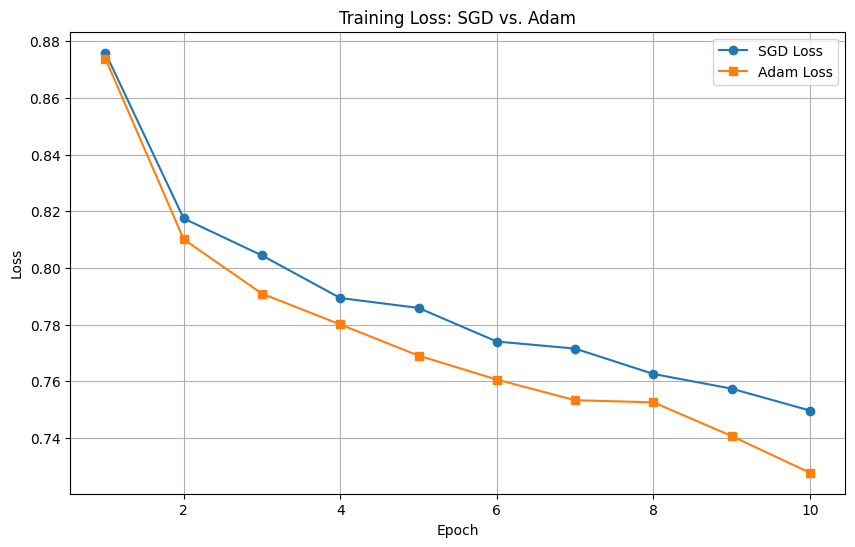

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

def load_and_preprocess_data(filepath):
    print("Loading data...")
    df = pd.read_csv(filepath)
    
    # Target variable
    target_col = 'hospital_death'
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in the dataset.")
        
    # Drop identifiers and columns that shouldn't be features
    drop_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    # Separate features and target
    X = df.drop(columns=[target_col])
    y = df[target_col].values
    
    # Identify categorical and numerical columns
    # Future warning fix for pandas 3.0 string vs object
    cat_cols = X.select_dtypes(include=['object', 'string']).columns
    num_cols = X.select_dtypes(exclude=['object', 'string']).columns
    
    print("Imputing missing values...")
    # Drop columns that are entirely NaN
    X = X.dropna(axis=1, how='all')
    # Update cols after dropping
    cat_cols = [c for c in cat_cols if c in X.columns]
    num_cols = [c for c in num_cols if c in X.columns]
    
    # Impute missing numerical values with median, fallback to 0 if median is NaN
    X[num_cols] = X[num_cols].fillna(X[num_cols].median()).fillna(0)
    
    # Impute missing categorical values with mode
    for col in cat_cols:
        X[col] = X[col].fillna(X[col].mode()[0])
        
    print("Encoding categorical variables...")
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    print("Splitting and normalizing data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

class BaselineDNN(nn.Module):
    def __init__(self, input_dim):
        super(BaselineDNN, self).__init__()
        # Shallow feedforward network with Batch Normalization and Dropout
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 1)
            # Removed Sigmoid here to use BCEWithLogitsLoss for numerical stability
        )
        
    def forward(self, x):
        return self.network(x)

def train_model(model, dataloader, optimizer, criterion, epochs=10):
    model.train()
    epoch_losses = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * batch_X.size(0)
            
        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
        
    return epoch_losses

def evaluate_model(model, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t).squeeze()
        preds = torch.sigmoid(logits)
        preds_binary = (preds >= 0.5).float()
        
    y_true = y_test_t.numpy()
    y_pred = preds_binary.numpy()
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return acc, prec, rec, f1

def main():
    data_path = os.path.join("data", "raw", "dataset.csv")
    assets_dir = os.path.join("assets", "generation_1")
    os.makedirs(assets_dir, exist_ok=True)
    
    # 1. Preprocess Data
    X_train, X_test, y_train, y_test = load_and_preprocess_data(data_path)
    
    # Convert to PyTorch tensors
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    
    input_dim = X_train.shape[1]
    
    # Calculate class weights for highly imbalanced data
    num_negatives = len(y_train) - np.sum(y_train)
    num_positives = np.sum(y_train)
    pos_weight_val = num_negatives / num_positives
    pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32)
    
    # 2. Train with SGD
    print("\n--- Training Model with SGD Optimizer ---")
    model_sgd = BaselineDNN(input_dim)
    optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    start_time_sgd = time.time()
    losses_sgd = train_model(model_sgd, train_loader, optimizer_sgd, criterion, epochs=10)
    train_time_sgd = time.time() - start_time_sgd
    
    # 3. Train with Adam
    print("\n--- Training Model with Adam Optimizer ---")
    model_adam = BaselineDNN(input_dim)
    optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
    start_time_adam = time.time()
    # Reusing the same class-weighted criterion
    losses_adam = train_model(model_adam, train_loader, optimizer_adam, criterion, epochs=10)
    train_time_adam = time.time() - start_time_adam
    
    # 4. Compare Loss Curves
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 11), losses_sgd, label='SGD Loss', marker='o')
    plt.plot(range(1, 11), losses_adam, label='Adam Loss', marker='s')
    plt.title('Training Loss: SGD vs. Adam')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plot_path = os.path.join(assets_dir, 'loss_curves.png')
    plt.savefig(plot_path)
    print(f"\nLoss curves saved to {plot_path}")
    
    # 5. Evaluate Best Model (Adam) on Test Set
    print("\n--- Evaluating Adam Model on Test Set ---")
    acc, prec, rec, f1 = evaluate_model(model_adam, X_test_t, y_test_t)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # 6. Save results to JSON
    results = {
        "model": "DNN Baseline (Adam)",
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
        "training_time_sgd_sec": float(train_time_sgd),
        "training_time_adam_sec": float(train_time_adam)
    }
    results_path = os.path.join(assets_dir, 'results.json')
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=4)
    print(f"\nResults successfully saved to {results_path}")
    
    print("\n[Clinical Note]: In critical care early warning systems, maximizing Recall is generally more important than Precision.")
    print("A false negative (failing to identify a deteriorating patient) can lead to delayed intervention and severe consequences or death.")
    print("While false positives cause alarm fatigue, missing a critically ill patient is a far more dangerous failure mode.")

if __name__ == "__main__":
    main()
